In [3]:
import numpy as np
data_path =  r"..\\Data_Full"
import os

#Files in the data folder of the type long_lat_100m_pop.jpg
#Getting populations only
all_paths = [os.path.join(data_path, f) for f in os.listdir(data_path) if f.endswith('.jpg')]

def extract_population(filename: str):
    """Integer between the last '_' and '.jpg', or None if not parseable."""
    if not filename.lower().endswith(".jpg"):
        return None
    stem = os.path.splitext(filename)[0]
    token = stem.split("_")[-1]
    try:
        return int(token)
    except ValueError:
        return None

paths, pops = [], []
skipped = 0
for name in sorted(os.listdir(data_path)):
    if not name.lower().endswith(".jpg"):
        continue
    p = extract_population(name)
    if p is None:
        skipped += 1
        continue
    paths.append(os.path.join(data_path, name))
    pops.append(p)

Total images: 88869, Skipped: 0


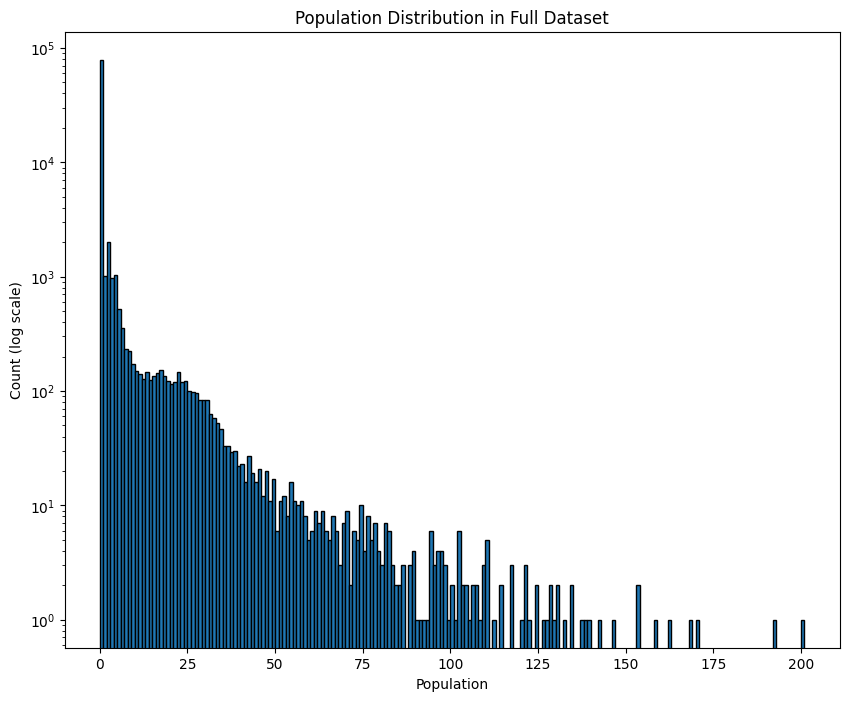

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.hist(pops, bins=np.max(pops), edgecolor='black')
plt.title("Population Distribution in Full Dataset")
plt.yscale('log')
plt.xlabel("Population")
plt.ylabel("Count (log scale)")
print(f"Total images: {len(paths)}, Skipped: {skipped}")
plt.savefig("population_histogram.png")